In [2]:
#from ben_notebook_functions import *
import warnings
warnings.filterwarnings("ignore")
import cartopy.geodesic as cgeo
import pandas as pd
import glob
import xarray as xr
import matplotlib.pyplot as plt
import datetime
#import ipdb
from scipy.ndimage.measurements import label
import numpy as np
import ipdb

In [1]:
cd ..

/home/users/cornkle/pythonWorkspace/proj_CEH


In [68]:
stash_dict={"sm":"STASH_m01s08i223",
            "lhfx":"STASH_m01s03i234",
            "shfx":"STASH_m01s03i217",
            "t2":"STASH_m01s03i236",
            "q2":"STASH_m01s03i237",
            "lw_nsfc":"STASH_m01s02i201",
            "sw_nsfc":"STASH_m01s01i201",
            "olr" : "STASH_m01s02i205",
            "u10" : "STASH_m01s03i225_2",
            "v10" : "STASH_m01s03i226_2",
            "prcp" : "STASH_m01s04i203",
            "toa_lw" : "STASH_m01s02i205",
            "low_cloud" : "STASH_m01s09i203"
           }

In [58]:
### FUNCTION FOR LOADING IN RAW DATA FILES - not actually used in this script, included as example.
def load_file(sim,date,hour,file_list,var):
    date_str="2006%02d%02d" % (date.month,date.day)
    hour=hour-1 #filenames are 1 hour BEHIND data timestamp
    date_str2=date_str
    date2 = date
    date_prev = date
    date_str_prev = date_str

    if (sim == 'sens') & (hour <= 5):
        date = date - datetime.timedelta(days=1)
        date_str = "2006%02d%02d" % (date.month,date.day)
        date_str2 = date_str
   
    ### this accesses day 2 of sensitivity runs
    if hour>23: # this accesses day 2 of sensitivity runs
        hour = hour-24
        if sim == "control":
            print('Control is continuous simulation, hour has to be <=23')
            return
        if (hour > 5):
            date2 = date + datetime.timedelta(days=1)
            date_str2 = "2006%02d%02d" % (date2.month,date2.day)
            date_str_prev = date_str2
        if (hour <= 5):
            date = date - datetime.timedelta(days=1)
            date_str = "2006%02d%02d" % (date.month,date.day)
            date_prev = date_prev + datetime.timedelta(days=1)
            date_str_prev = "2006%02d%02d" % (date_prev.month,date_prev.day)

    if sim=="sens":
        #root_str="/gws/nopw/j04/lmcs/filtered_soil_moisture_runs/u-da520/20060725T0500Z/Sahel/4km/RA3/um/"
        
        root_str=glob.glob("/gws/nopw/j04/lmcs/sensitivity_runs_wg_mcs/{}T0600Z/*/{}T0600Z/Sahel/1p5km/RA3/um/".format(date_str,date_str2))[0]
    elif sim=="control":
        root_str="/gws/nopw/j04/lmcs/u-cy045_control_run/u-cy045/{}T0000Z/Sahel/1p5km/RA3/um/".format(date_str)

    #print('Reading', root_str+"{}_{}_T{:02d}.nc".format(file_list,date_str_prev,hour))

    if file_list=="sensible_hfx_control":
        data=xr.open_dataset("/gws/nopw/j04/lmcs/bmaybee/sensible_heat_fluxes/{}_sensible_heat_flux.nc".format(date_str2))["surface_upward_sensible_heat_flux"
        ].isel(time=slice(hour,hour+1)) # Sahel - time slice necessary to keep length 1 time axis.
        return data.rename({"longitude":"lon","latitude":"lat"})

    
    # elif sim=="sens" and date_str==date_prev and hour==5:
    #     data=xr.open_dataset("/gws/nopw/j04/lmcs/bmaybee/Filtered_SM_initialisations/{}_05Z_SM_filter_wg_mcs.nc".format(date_str))[var].sel(
    #                         grid_longitude_t=slice(348,378),grid_latitude_t=slice(9,19)).isel(ATM_SOIL=0)
    #     return data.rename({"grid_longitude_t":"lon","grid_latitude_t":"lat"})
            
    else:
        data=xr.open_dataset(root_str+"{}_{}_T{:02d}.nc".format(file_list,date_str_prev,hour))[var]#.sel(
                        #grid_longitude_t=slice(348,380),grid_latitude_t=slice(8,28)) # Very big area, but crucially avoids all coastlines
        data=data#.sel(grid_longitude_t=slice(348,378),grid_latitude_t=slice(9,19)) # RESTRICT TO CORE SAHEL
        print('Reading', root_str+"{}_{}_T{:02d}.nc".format(file_list,date_str_prev,hour))
        if file_list=="soil_moistures":
            data=data.isel(ATM_SOIL=0)
        try:
            data=data.isel(height_1_5m=0)
        except:
            pass
            
    return data.rename({"grid_longitude_t":"lon","grid_latitude_t":"lat"})

In [19]:
def load_filepath(sim,date,hour,file_list):
    date_str="2006%02d%02d" % (date.month,date.day)
    hour=hour-1 #filenames are 1 hour BEHIND data timestamp
    date_str2=date_str
    date2 = date
    date_prev = date
    date_str_prev = date_str

    if (sim == 'sens') & (hour <= 5):
        date = date - datetime.timedelta(days=1)
        date_str = "2006%02d%02d" % (date.month,date.day)
        date_str2 = date_str
   
    ### this accesses day 2 of sensitivity runs
    if hour>23: # this accesses day 2 of sensitivity runs
        hour = hour-24
        if sim == "control":
            print('Control is continuous simulation, hour has to be <=23')
            return
        if (hour > 5):
            date2 = date + datetime.timedelta(days=1)
            date_str2 = "2006%02d%02d" % (date2.month,date2.day)
            date_str_prev = date_str2
        if (hour <= 5):
            date = date - datetime.timedelta(days=1)
            date_str = "2006%02d%02d" % (date.month,date.day)
            date_prev = date_prev + datetime.timedelta(days=1)
            date_str_prev = "2006%02d%02d" % (date_prev.month,date_prev.day)

    if sim=="sens":
        #root_str="/gws/nopw/j04/lmcs/filtered_soil_moisture_runs/u-da520/20060725T0500Z/Sahel/4km/RA3/um/"
        
        root_str=glob.glob("/gws/nopw/j04/lmcs/sensitivity_runs_wg_mcs/{}T0600Z/*/{}T0600Z/Sahel/1p5km/RA3/um/".format(date_str,date_str2))[0]
    elif sim=="control":
        root_str=glob.glob("/gws/nopw/j04/lmcs/u-cy045_control_run/u-cy045/{}T0000Z/Sahel/1p5km/RA3/um/".format(date_str))[0]
            
    return root_str+"{}_{}_T{:02d}.nc".format(file_list,date_str_prev,hour)

In [6]:
files = sorted(glob.glob("/gws/nopw/j04/lmcs/u-cy045_control_run/u-cy045/*/Sahel/1p5km/RA3/um/surface_vars*.nc"))

In [92]:
pickf = files[24*5:110+24*5]#[24:100]

In [114]:
pickf[0]

'/gws/nopw/j04/lmcs/u-cy045_control_run/u-cy045/20060729T0000Z/Sahel/1p5km/RA3/um/surface_vars_20060729_T22.nc'

In [115]:
pickf[-1]

'/gws/nopw/j04/lmcs/u-cy045_control_run/u-cy045/20060803T0000Z/Sahel/1p5km/RA3/um/surface_vars_20060803_T11.nc'

In [85]:
xr.open_dataset(pickf[0])

<xarray.Dataset>
Dimensions:                     (grid_longitude_t: 3360, grid_latitude_t: 2260,
                                 bounds2: 2, T1HR_0: 1, T1HR_MN_rad_diag: 1,
                                 T1HR_MN: 1, grid_longitude_uv: 3360,
                                 grid_latitude_uv: 2261, height_10m: 1,
                                 T20M: 3, T20M_MN: 3, height_1_5m: 1,
                                 T20M_MAX: 3, T1HR: 1)
Coordinates: (12/17)
  * grid_longitude_t            (grid_longitude_t) float64 340.0 340.0 ... 385.4
    longitude_t                 (grid_latitude_t, grid_longitude_t) float64 ...
  * grid_latitude_t             (grid_latitude_t) float64 0.00675 ... 30.5
    latitude_t                  (grid_latitude_t, grid_longitude_t) float64 ...
  * T1HR_0                      (T1HR_0) datetime64[ns] 2006-07-25T23:00:00
  * T1HR_MN_rad_diag            (T1HR_MN_rad_diag) datetime64[ns] 2006-07-25T...
    ...                          ...
  * height_10m                  (height_10m) float64 10.0
  * T20M                        (T20M) datetime64[ns] 2006-07-25T22:16:30 ......
  * T20M_MN                     (T20M_MN) datetime64[ns] 2006-07-25T22:16:30 ...
  * height_1_5m                 (height_1_5m) float64 1.5
  * T20M_MAX                    (T20M_MAX) datetime64[ns] 2006-07-25T22:16:30...
  * T1HR                        (T1HR) datetime64[ns] 2006-07-25T23:00:00
Dimensions without coordinates: bounds2
Data variables: (12/45)
    rotated_latitude_longitude  |S1 ...
    grid_longitude_t_bounds     (grid_longitude_t, bounds2) float64 ...
    grid_latitude_t_bounds      (grid_latitude_t, bounds2) float64 ...
    STASH_m01s00i024            (T1HR_0, grid_latitude_t, grid_longitude_t) float64 ...
    STASH_m01s00i025            (T1HR_0, grid_latitude_t, grid_longitude_t) float64 ...
    STASH_m01s00i409            (T1HR_0, grid_latitude_t, grid_longitude_t) float64 ...
    ...                          ...
    STASH_m01s30i404            (T1HR_0, grid_latitude_t, grid_longitude_t) float64 ...
    STASH_m01s30i405            (T1HR_0, grid_latitude_t, grid_longitude_t) float64 ...
    STASH_m01s30i406            (T1HR_0, grid_latitude_t, grid_longitude_t) float64 ...
    STASH_m01s30i461            (T1HR_0, grid_latitude_t, grid_longitude_t) float64 ...
    STASH_m01s30i462            (T1HR_MN, grid_latitude_t, grid_longitude_t) float64 ...
    STASH_m01s30i463            (T1HR_MN, grid_latitude_t, grid_longitude_t) float64 ...
Attributes:
    Conventions:  CF-1.6
    source:       Met Office Unified Model v12.0

In [121]:
dlist = []
hour = []
date = []
stash = stash_dict['toa_lw']
for f in pickf:
    ds = xr.open_dataset(f)
    try:
        ds=ds.rename({"grid_latitude_t":"latitude","grid_longitude_t":"longitude"})
    except:
        ipdb.set_trace()
    ds=ds.assign_coords({"longitude":(ds.longitude-360)})
    ds = ds[stash]
    try: 
        ds = ds.rename({"T1HR_MN_rad_diag" : "time"})
        date.append(ds.time.values)
        dt = np.datetime64(ds.time.values[0])
        hour.append(pd.Timestamp(dt).hour)
    except:
        try:
            try:
                ds = ds.rename({"T1HR" : "time"}).isel(bounds2=0)
            except:
                ds = ds.rename({"T1HR" : "time"})
            date.append(ds.time.values)
            dt = np.datetime64(ds.time.values[0])
            hour.append(pd.Timestamp(dt).hour)
        except:
            try:
                ds = ds.rename({"T20M" : "time"}).isel(height_1_5m=0)
               
                date.append(ds.time.values[-1])
                dt = np.datetime64(ds.time.values[-1])
                hour.append(pd.Timestamp(dt).hour)
                ds = ds.mean("time")
            except:
                ipdb.set_trace()
    
    ds = ds.mean(['latitude','longitude'])  #sel(longitude=slice(-15,20), latitude=slice(9,18)).
    #ipdb.set_trace()

    
    dlist.append(ds)
    del ds

In [122]:
dsfull = xr.concat(dlist, dim='time')

In [123]:
dsfull

<xarray.DataArray 'STASH_m01s02i205' (time: 110)>
array([253.06271001, 252.72855283, 257.40519724, 257.60314831,
       256.34047679, 255.37336271, 255.15978156, 257.02277542,
       261.55095283, 267.71409831, 273.83268932, 278.48947506,
       281.7027646 , 283.09088783, 281.72652401, 277.74842064,
       272.37573394, 266.94152516, 261.82844073, 257.16357316,
       253.30417555, 251.1664852 , 250.26103008, 249.60869199,
       249.06433047, 248.79935701, 253.35687413, 254.05063134,
       253.0446887 , 252.04635603, 252.02777404, 254.23515474,
       259.265932  , 265.69690428, 271.92281556, 277.27233708,
       281.09355256, 282.31831695, 280.68362039, 277.10509705,
       272.36461734, 267.17151514, 262.65838263, 259.17769983,
       256.33216791, 254.88147402, 254.27357517, 253.93879628,
       253.54786152, 253.1076077 , 256.10653831, 256.71781103,
       255.99351895, 255.09572394, 254.67896477, 256.62666347,
       261.34124739, 267.53581821, 272.99164864, 277.2701071 ,
       280.99063017, 282.67065479, 281.45733866, 278.09795155,
       273.33278465, 268.50722066, 264.56623002, 261.03184321,
       258.42076105, 257.00238549, 256.51800636, 256.1015997 ,
       255.44655074, 254.66358847, 257.84328056, 258.21285214,
       256.72279165, 254.9809117 , 253.98470651, 254.88349551,
       258.47304083, 263.76913249, 269.23969894, 274.03528337,
       277.36885469, 278.77061156, 277.51241404, 273.74505325,
       268.66407383, 263.69023825, 259.68244245, 255.99079346,
       252.82224397, 250.86786001, 249.74429874, 248.89479395,
       248.13593379, 247.60391736, 252.67108497, 253.43559663,
       252.27088205, 250.80303291, 250.05729587, 251.29715767,
       255.30244514, 261.12719553, 266.93360592, 271.89649555,
       275.72923642, 277.43810204])
Coordinates:
  * time     (time) datetime64[ns] 2006-07-29T23:00:00 ... 2006-08-03T12:00:00

In [124]:
dstime = dsfull.assign_coords(hour=('time', hour))

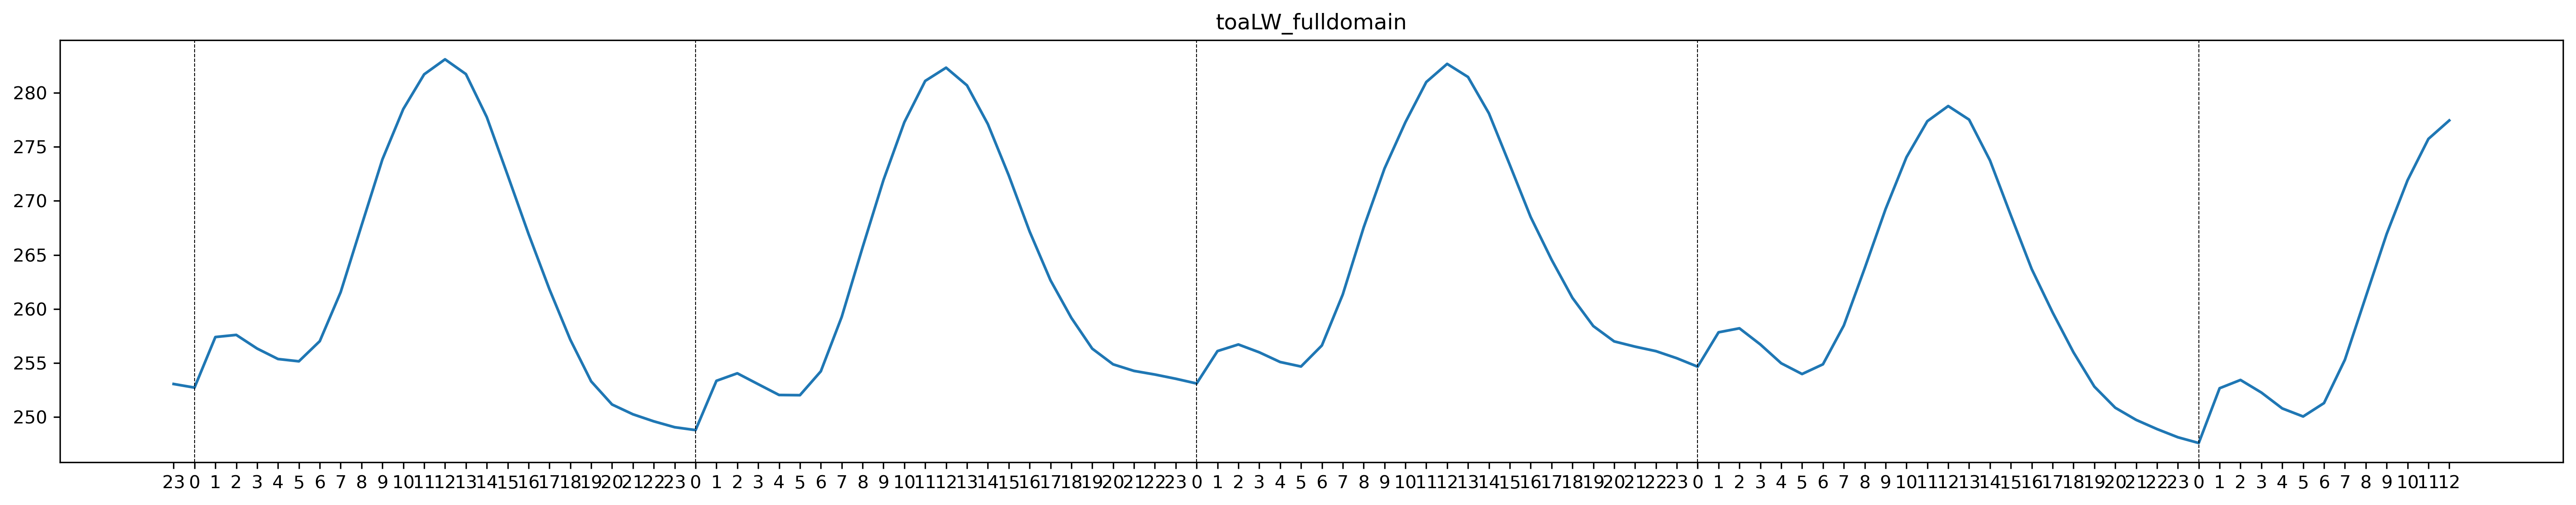

In [126]:
f=plt.figure(figsize=(20, 4), dpi=300)
ax = f.add_subplot(111)
plt.plot(dstime)
plt.xticks(np.arange(len(hour)), labels=hour)
plt.title('toaLW_fulldomain')
for vl in [1,1+24,1+2*24, 1+3*24, 1+4*24]:
    ax.axvline(vl, linestyle='dashed', color='k', linewidth=0.5)
plt.tight_layout()
f.savefig('/home/users/cornkle/pythonWorkspace/proj_CEH/control_toaLW_fulldomain.jpg')

In [69]:
example=load_file("control",pd.Timestamp("2006-08-27"),17,"surface_vars",stash_dict["low_cloud"])[0,:,:]

Reading /gws/nopw/j04/lmcs/u-cy045_control_run/u-cy045/20060827T0000Z/Sahel/1p5km/RA3/um/surface_vars_20060827_T16.nc


In [70]:
example

<xarray.DataArray 'STASH_m01s09i203' (lat: 2260, lon: 3360)>
[7593600 values with dtype=float64]
Coordinates:
  * lon          (lon) float64 340.0 340.0 340.0 340.0 ... 385.3 385.3 385.4
    longitude_t  (lat, lon) float64 ...
  * lat          (lat) float64 0.00675 0.02025 0.03375 ... 30.48 30.49 30.5
    latitude_t   (lat, lon) float64 ...
    T1HR         datetime64[ns] 2006-08-27T17:00:00
Attributes:
    long_name:          LOW CLOUD AMOUNT
    standard_name:      low_type_cloud_area_fraction
    units:              1
    cell_methods:       T1HR: point
    grid_mapping:       rotated_latitude_longitude
    um_version:         12.0
    um_stash_source:    m01s09i203
    packing_method:     quantization
    precision_measure:  binary
    precision_value:    -6

In [22]:
dt = np.datetime64(example.T1HR.values)
pd.Timestamp(dt).hour

17

Reading /gws/nopw/j04/lmcs/sensitivity_runs_wg_mcs/20060827T0600Z/u-di730/20060827T0600Z/Sahel/1p5km/RA3/um/surface_vars_20060827_T18.nc
Reading /gws/nopw/j04/lmcs/sensitivity_runs_wg_mcs/20060826T0600Z/u-di731/20060827T0600Z/Sahel/1p5km/RA3/um/surface_vars_20060827_T18.nc
Reading /gws/nopw/j04/lmcs/u-cy045_control_run/u-cy045/20060827T0000Z/Sahel/1p5km/RA3/um/surface_vars_20060827_T18.nc


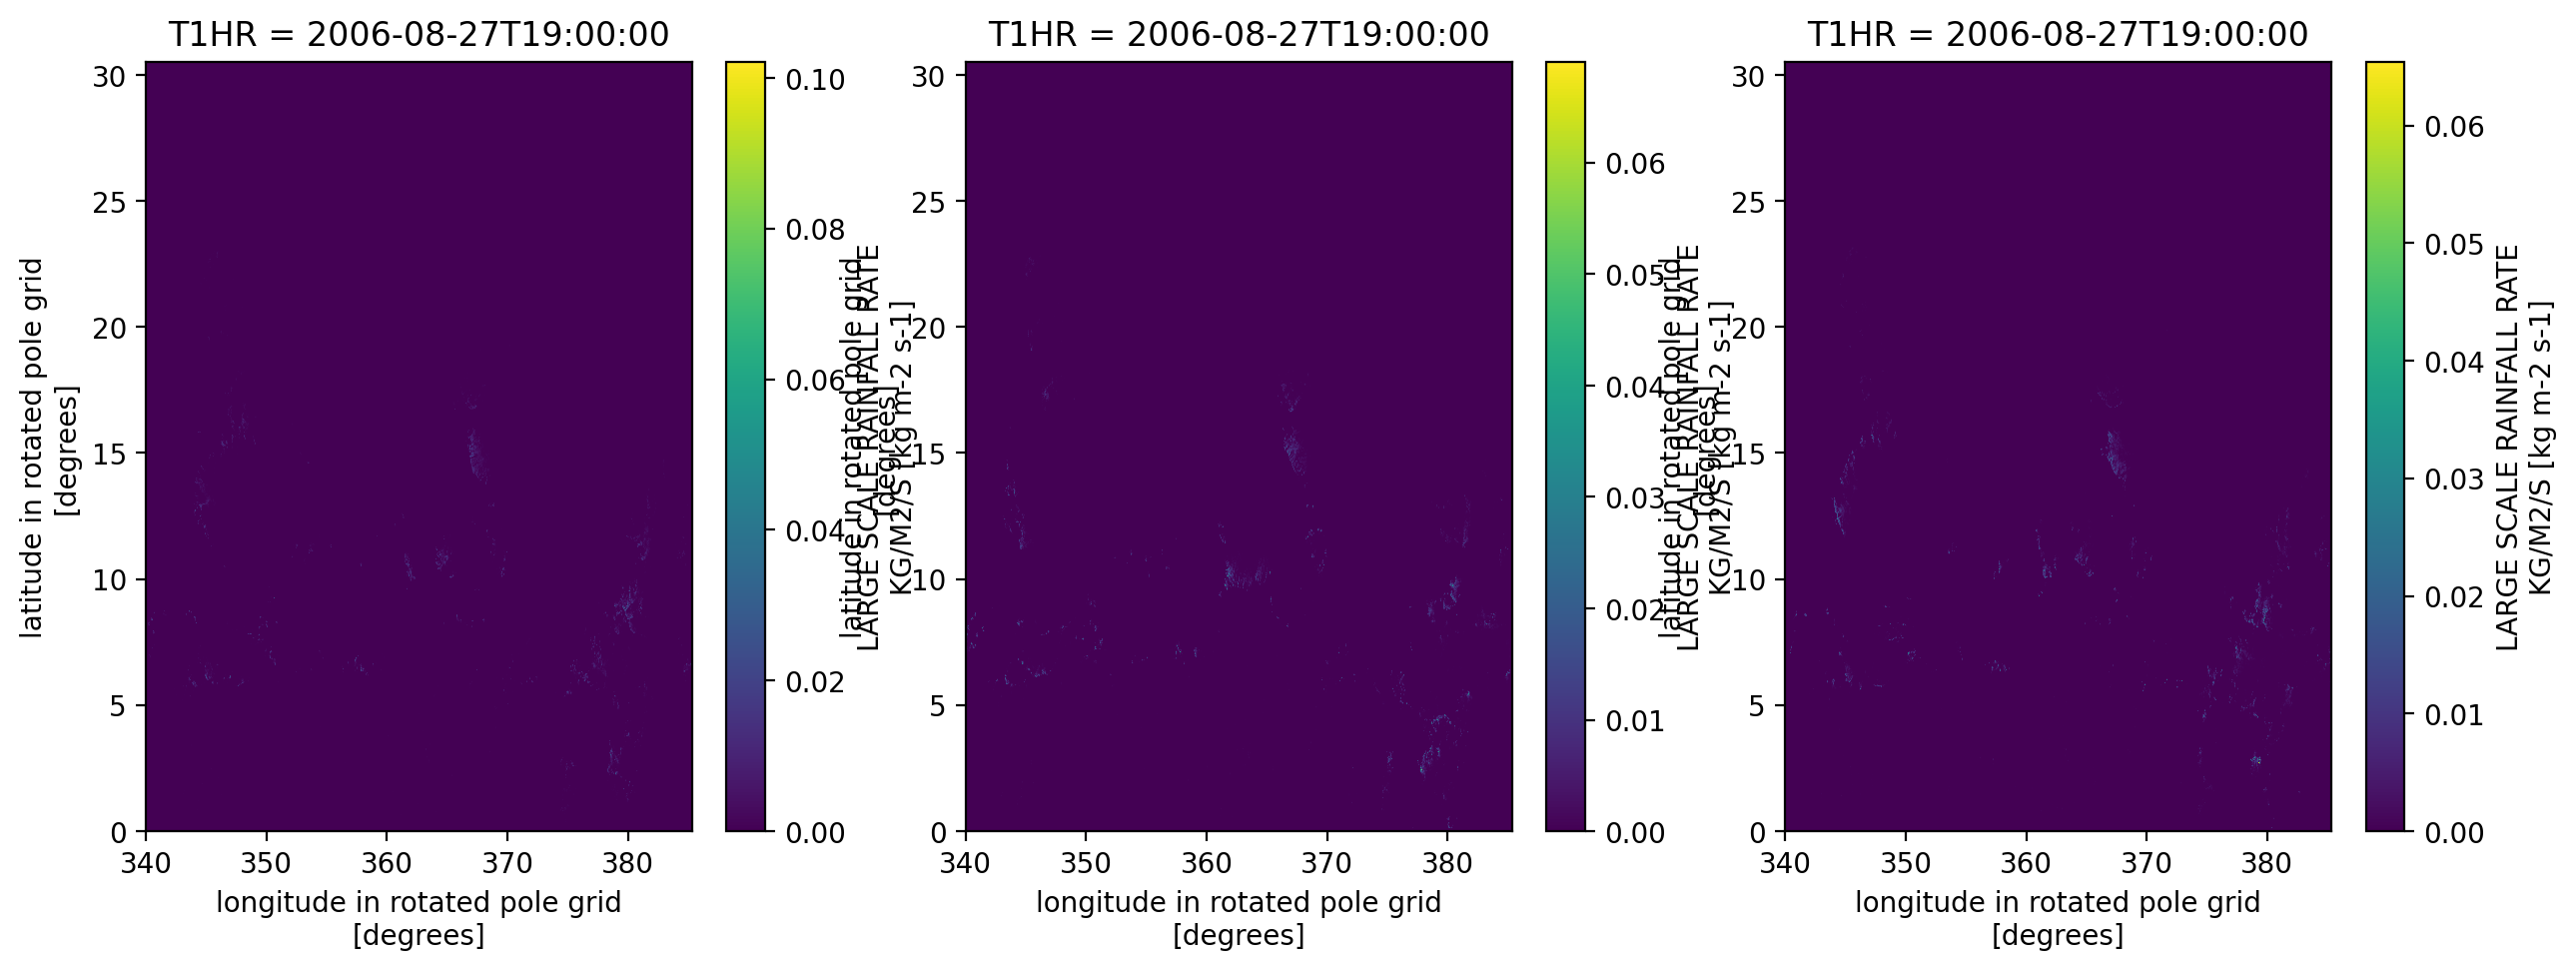

In [9]:
f = plt.figure(figsize=(15,5), dpi=200)
ax = f.add_subplot(1,3,1)

##day1 sensitivity
# get soil moisture field from sensitivity run at 18UTC on day 1 - would do hour=42 for 18UTC on day 2.
example=load_file("sens",pd.Timestamp("2006-08-27"),19,"surface_vars",stash_dict["prcp"])[0,:,:]
example.plot() # note function set to load Sahel subdomain only. Tracking done on full domain.

ax = f.add_subplot(1,3,2)

# day 2 sensitivity
# get soil moisture field from sensitivity run at 18UTC on day 1 - would do hour=42 for 18UTC on day 2.
example=load_file("sens",pd.Timestamp("2006-08-26"),24+19,"surface_vars",stash_dict["prcp"])[0,:,:]
example.plot() # note function set to load Sahel 

ax = f.add_subplot(1,3,3)
# control time starts on 25/07
# get soil moisture field from sensitivity run at 18UTC on day 1 - would do hour=42 for 18UTC on day 2.
example=load_file("control",pd.Timestamp("2006-08-27"),19,"surface_vars",stash_dict["prcp"])[0,:,:]
example.plot() # note function set to load Sahel subdomain only. Tracking done on full domain.

In [16]:
#Domain goes from 20W to 25E and from 0-30N

In [20]:
print(example.lat[0].values)
print(example.lat[-1].values)
print(example.lon[0].values-360)
print(example.lon[-1].values-360)

0.00675
30.50325
-19.99324999999999
25.353250000000003


Reading /gws/nopw/j04/lmcs/sensitivity_runs_wg_mcs/20060827T0600Z/u-de722/20060827T0600Z/Sahel/1p5km/RA3/um/soil_moistures_20060827_T18.nc
Reading /gws/nopw/j04/lmcs/sensitivity_runs_wg_mcs/20060826T0600Z/u-de721/20060827T0600Z/Sahel/1p5km/RA3/um/soil_moistures_20060827_T18.nc
Reading /gws/nopw/j04/lmcs/u-cy045_control_run/u-cy045/20060827T0000Z/Sahel/1p5km/RA3/um/soil_moistures_20060827_T18.nc


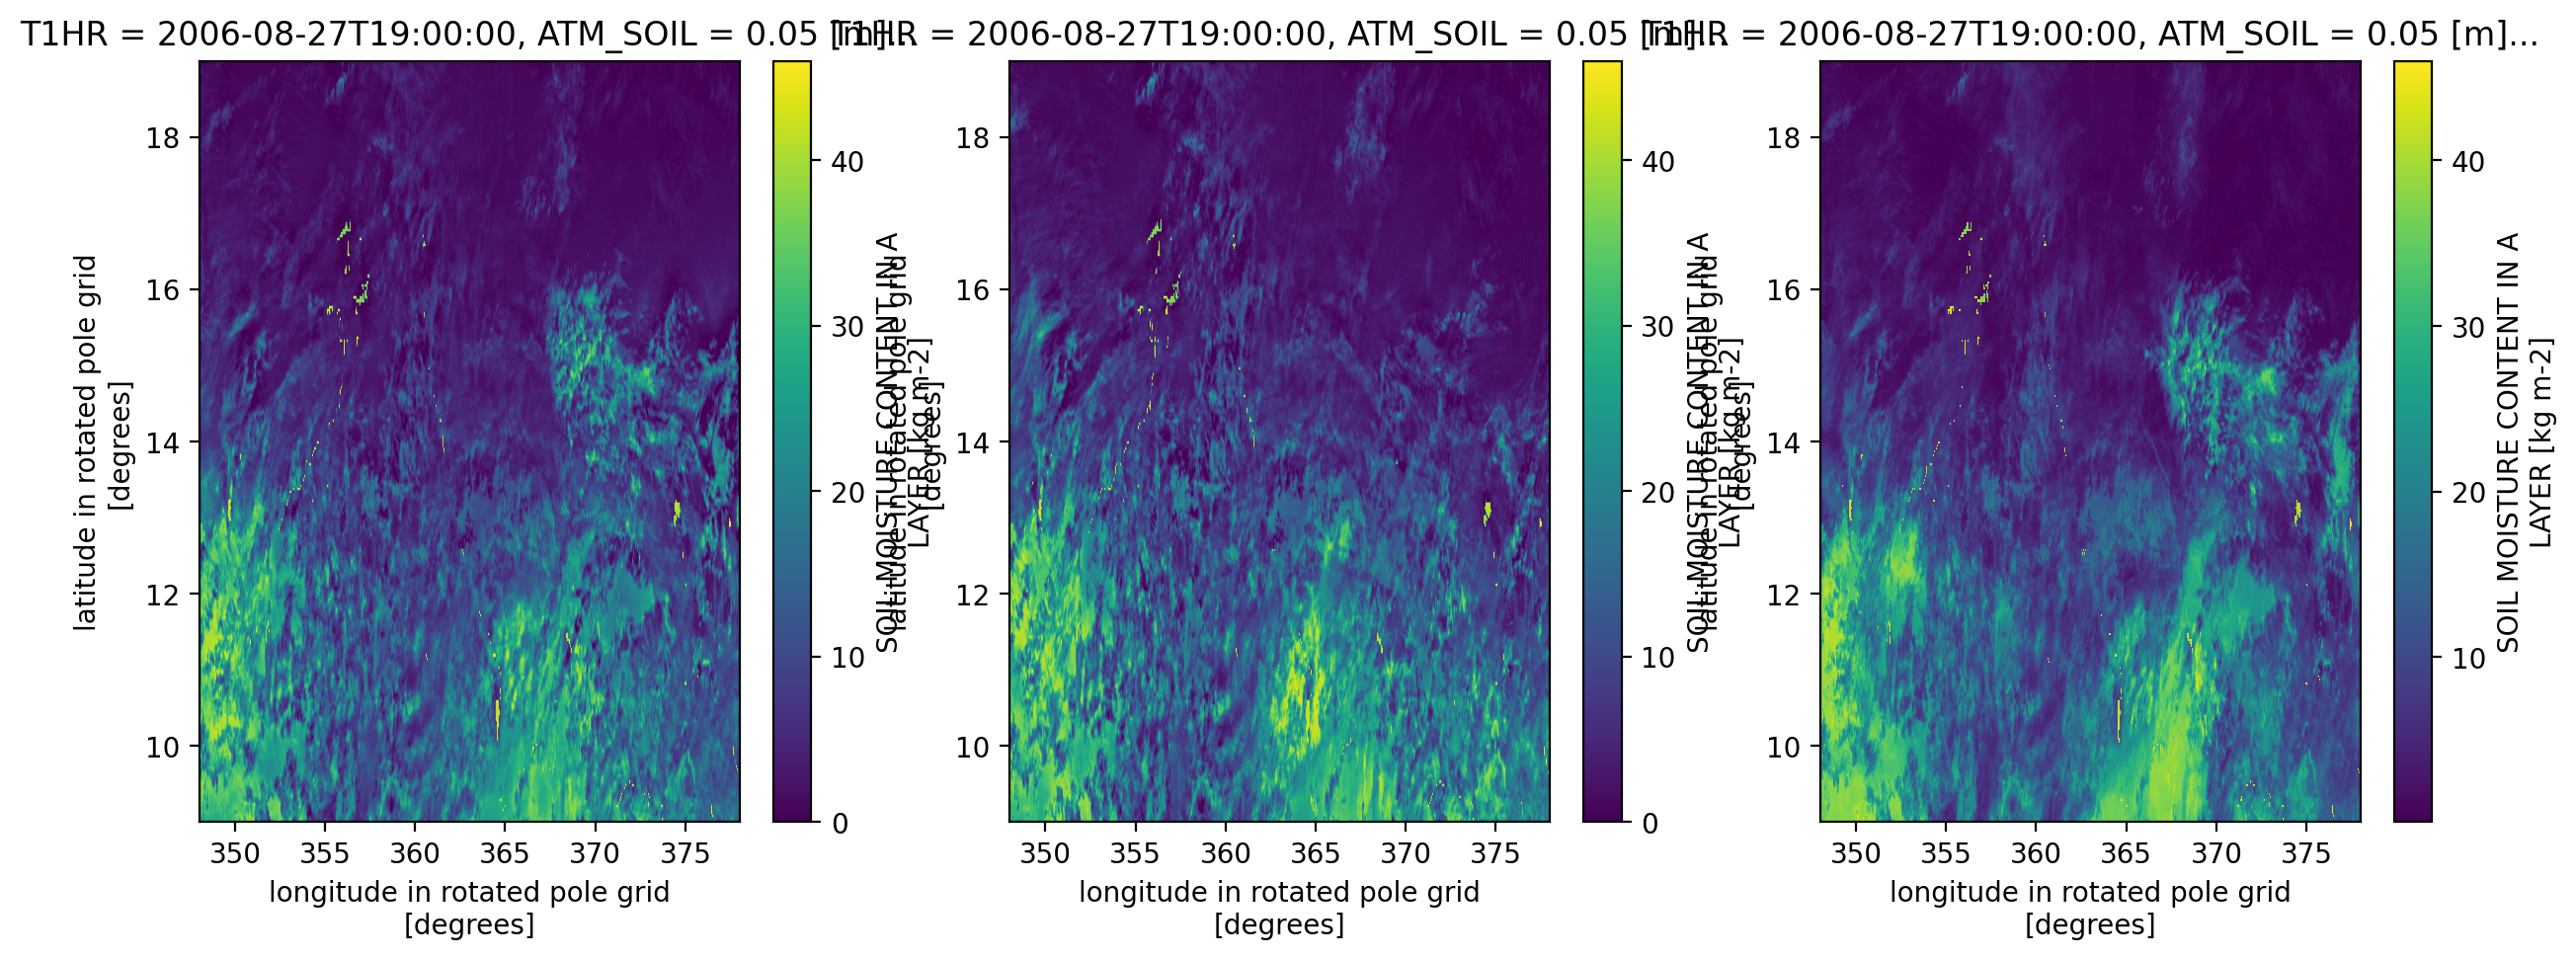

In [39]:
f = plt.figure(figsize=(15,5), dpi=200)
ax = f.add_subplot(1,3,1)

##day1 sensitivity
# get soil moisture field from sensitivity run at 18UTC on day 1 - would do hour=42 for 18UTC on day 2.
example=load_file("sens",pd.Timestamp("2006-08-27"),19,"soil_moistures",stash_dict["sm"])[0,:,:]
example.plot() # note function set to load Sahel subdomain only. Tracking done on full domain.

ax = f.add_subplot(1,3,2)

# day 2 sensitivity
# get soil moisture field from sensitivity run at 18UTC on day 1 - would do hour=42 for 18UTC on day 2.
example=load_file("sens",pd.Timestamp("2006-08-26"),24+19,"soil_moistures",stash_dict["sm"])[0,:,:]
example.plot() # note function set to load Sahel 

ax = f.add_subplot(1,3,3)
# control time starts on 25/07
# get soil moisture field from sensitivity run at 18UTC on day 1 - would do hour=42 for 18UTC on day 2.
example=load_file("control",pd.Timestamp("2006-08-27"),19,"soil_moistures",stash_dict["sm"])[0,:,:]
example.plot() # note function set to load Sahel subdomain only. Tracking done on full domain.

In [10]:
def filter_tab(data):
    data['date'] = pd.to_datetime(data[['year', 'month', 'day']])
    
    # Define the date range
    start_date = '2006-08-01'
    end_date = '2006-09-02'
    box = [-15,20,6,13.5]
    
    # Filter the data within the date range
    filtered_data = data[(data['date'] >= start_date) & (data['date'] <= end_date)]
    filtered_data = filtered_data[(filtered_data['minlon'] >= box[0]) & (filtered_data['maxlon'] <= box[1]) & (filtered_data['minlat'] >= box[2]) & (filtered_data['maxlat'] <= box[3])]
    return filtered_data

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


# Load the CSV file
base = '/home/users/cornkle/pythonWorkspace/proj_CEH/'
file_path = 'SM_runs_day1_snapshots.csv'  # Replace with your actual file path

data = pd.read_csv(base + file_path)
sensitivity_data = pd.read_csv(base + 'SM_runs_day2_snapshots.csv')
control_data = pd.read_csv(base + 'SM_runs_control_snapshots.csv')

data = filter_tab(data)
sensitivity_data = filter_tab(sensitivity_data)
control_data = filter_tab(control_data)

# Find the intersection of dates
common_dates = np.intersect1d(data['date'], sensitivity_data['date'])
common_dates = np.intersect1d(common_dates, control_data['date'])

# Filter each dataset to include only the common dates
data = data[data['date'].isin(common_dates)]
sensitivity_data = sensitivity_data[sensitivity_data['date'].isin(common_dates)]
control_data = control_data[control_data['date'].isin(common_dates)]

print('Number of unique days, Day1', len(np.unique(data['date'])))
print('Number of unique days, Day2', len(np.unique(sensitivity_data['date'])))
print('Number of unique days, Control', len(np.unique(control_data['date'])))

FileNotFoundError: [Errno 2] No such file or directory: '/home/users/cornkle/pythonWorkspace/proj_CEH/SM_runs_day1_snapshots.csv'

In [126]:
def check_full_day_unique_hours(data, date_columns):
    # Combine the date columns to create a datetime column
    data['date'] = pd.to_datetime(data[date_columns])

    # Group by date and count the number of unique hours for each date
    date_hour_counts = data.groupby('date')['hour'].nunique()

    # Check if all dates have exactly 24 unique hours
    incomplete_dates = date_hour_counts[date_hour_counts != 24].index

    return incomplete_dates

# Check each dataset
missing_hours1 = check_full_day_unique_hours(data, ['year', 'month', 'day'])
missing_hours2 = check_full_day_unique_hours(sensitivity_data, ['year', 'month', 'day'])
missing_hours3 = check_full_day_unique_hours(control_data, ['year', 'month', 'day'])

# Display results
if missing_hours1.empty:
    print("Day1: All dates have exactly 24 hours of data.")
else:
    print("Day1: The following dates do not have 24 hours of data:")
    print(missing_hours1)

if missing_hours2.empty:
    print("Day2: All dates have exactly 24 hours of data.")
else:
    print("Day2: The following dates do not have 24 hours of data:")
    print(missing_hours2)

if missing_hours3.empty:
    print("Control: All dates have exactly 24 hours of data.")
else:
    print("Control: The following dates do not have 24 hours of data:")
    print(missing_hours3)


Day1: The following dates do not have 24 hours of data:
DatetimeIndex(['2006-08-19', '2006-09-01'], dtype='datetime64[ns]', name='date', freq=None)
Day2: All dates have exactly 24 hours of data.
Control: The following dates do not have 24 hours of data:
DatetimeIndex(['2006-08-19', '2006-09-01'], dtype='datetime64[ns]', name='date', freq=None)


In [127]:
def filter_complete_dates(data, date_columns, incomplete_dates):
    # Combine the date columns to create a datetime column
    data['date'] = pd.to_datetime(data[date_columns])
    
    # Filter out incomplete dates
    complete_data = data[~data['date'].isin(incomplete_dates)]
    
    return complete_data

# Find the union of all incomplete dates
all_incomplete_dates = np.union1d(np.union1d(missing_hours1, missing_hours2), missing_hours3)

# Filter out incomplete dates from each dataset
data = filter_complete_dates(data, ['year', 'month', 'day'], all_incomplete_dates)
sensitivity_data = filter_complete_dates(sensitivity_data, ['year', 'month', 'day'], all_incomplete_dates)
control_data = filter_complete_dates(control_data, ['year', 'month', 'day'], all_incomplete_dates)

In [128]:
print('Number of unique days, Day1', len(np.unique(data['date'])))
print('Number of unique days, Day2', len(np.unique(sensitivity_data['date'])))
print('Number of unique days, Control', len(np.unique(control_data['date'])))

Number of unique days, Day1 30
Number of unique days, Day2 30
Number of unique days, Control 30


<Axes: >

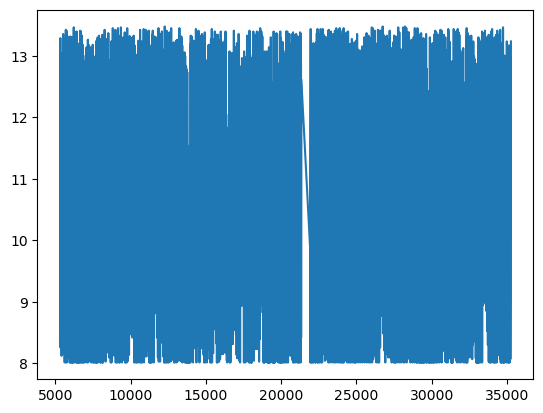

In [129]:
data['tminlat'].plot()

(20737,)
(22378,)
(20337,)
(6559,)
(6668,)
(6297,)
(2738,)
(2830,)
(2894,)
(859,)
(871,)
(967,)


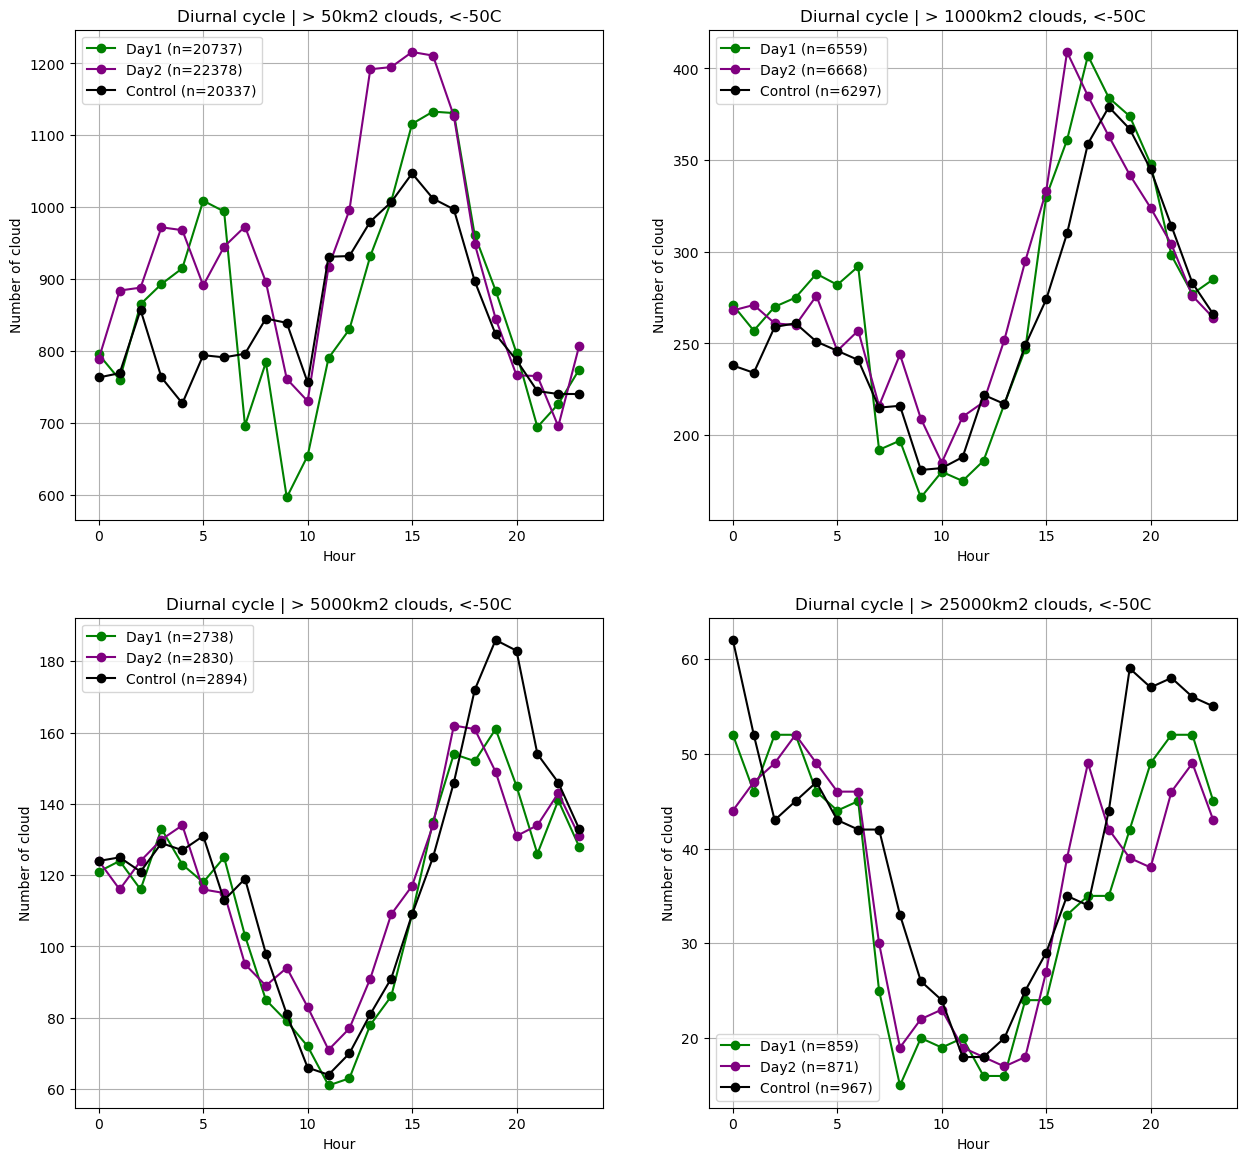

In [130]:
###########################################################
# Extract the relevant columns
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=3)
hours = data['hour']
print(hours.shape)
# Calculate the percentage of storms per hour
hour_counts = hours.value_counts().sort_index()
hour_percentage = (hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / hour_counts.sum() /hour_counts.sum()*100

# Create the plot
f= plt.figure(figsize=(15, 14))
ax = f.add_subplot(2,2,1)
plt.plot(hour_percentage.index, hour_percentage.values, label='Day1 (n={})'.format(len(hours)), color='green', marker='o')
#####


sensitivity_hours = sensitivity_data['hour']
print(sensitivity_hours.shape)
sensitivity_hour_counts = sensitivity_hours.value_counts().sort_index()
sensitivity_hour_percentage = (sensitivity_hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / sensitivity_hour_counts.sum()  / sensitivity_hour_counts.sum() *100
plt.plot(sensitivity_hour_percentage.index, sensitivity_hour_percentage.values, label='Day2 (n={})'.format(len(sensitivity_hours)), color='purple', marker='o')
############


control_hours = control_data['hour']
print(control_hours.shape)
control_hour_counts = control_hours.value_counts().sort_index()
control_hour_percentage = (control_hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / sensitivity_hour_counts.sum() / control_hour_counts.sum()*100
plt.plot(control_hour_percentage.index, control_hour_percentage.values, label='Control (n={})'.format(len(control_hours)), color='black', marker='o')

plt.xlabel('Hour')
plt.ylabel('Number of cloud')
plt.title('Diurnal cycle | > 50km2 clouds, <-50C')
plt.legend()
plt.grid(True)

ax = f.add_subplot(2,2,2)
hours = data[data['area']>=444]['hour']
print(hours.shape)
# Calculate the percentage of storms per hour
hour_counts = hours.value_counts().sort_index()
hour_percentage = (hour_counts)
plt.plot(hour_percentage.index, hour_percentage.values, label='Day1 (n={})'.format(len(hours)), color='green', marker='o')
#####


sensitivity_hours = sensitivity_data[sensitivity_data['area']>=444]['hour']
print(sensitivity_hours.shape)
sensitivity_hour_counts = sensitivity_hours.value_counts().sort_index()
sensitivity_hour_percentage = (sensitivity_hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / sensitivity_hour_counts.sum()  / sensitivity_hour_counts.sum() *100
plt.plot(sensitivity_hour_percentage.index, sensitivity_hour_percentage.values, label='Day2 (n={})'.format(len(sensitivity_hours)), color='purple', marker='o')
############


control_hours = control_data[control_data['area']>=444]['hour']
print(control_hours.shape)
control_hour_counts = control_hours.value_counts().sort_index()
control_hour_percentage = (control_hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / sensitivity_hour_counts.sum() / control_hour_counts.sum()*100
plt.plot(control_hour_percentage.index, control_hour_percentage.values, label='Control (n={})'.format(len(control_hours)), color='black', marker='o')

plt.xlabel('Hour')
plt.ylabel('Number of cloud')
plt.title('Diurnal cycle | > 1000km2 clouds, <-50C')
plt.legend()
plt.grid(True)
##################################################

ax = f.add_subplot(2,2,3)
hours = data[data['area']>=2222]['hour']
print(hours.shape)
# Calculate the percentage of storms per hour
hour_counts = hours.value_counts().sort_index()
hour_percentage = (hour_counts)
plt.plot(hour_percentage.index, hour_percentage.values, label='Day1 (n={})'.format(len(hours)), color='green', marker='o')
#####


sensitivity_hours = sensitivity_data[sensitivity_data['area']>=2222]['hour']
print(sensitivity_hours.shape)
sensitivity_hour_counts = sensitivity_hours.value_counts().sort_index()
sensitivity_hour_percentage = (sensitivity_hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / sensitivity_hour_counts.sum()  / sensitivity_hour_counts.sum() *100
plt.plot(sensitivity_hour_percentage.index, sensitivity_hour_percentage.values, label='Day2 (n={})'.format(len(sensitivity_hours)), color='purple', marker='o')
############


control_hours = control_data[control_data['area']>=2222]['hour']
print(control_hours.shape)
control_hour_counts = control_hours.value_counts().sort_index()
control_hour_percentage = (control_hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / sensitivity_hour_counts.sum() / control_hour_counts.sum()*100
plt.plot(control_hour_percentage.index, control_hour_percentage.values, label='Control (n={})'.format(len(control_hours)), color='black', marker='o')

plt.xlabel('Hour')
plt.ylabel('Number of cloud')
plt.title('Diurnal cycle | > 5000km2 clouds, <-50C')
plt.legend()
plt.grid(True)

##################################################

ax = f.add_subplot(2,2,4)
hours = data[data['area']>=11111]['hour']
print(hours.shape)
# Calculate the percentage of storms per hour
hour_counts = hours.value_counts().sort_index()
hour_percentage = (hour_counts)
plt.plot(hour_percentage.index, hour_percentage.values, label='Day1 (n={})'.format(len(hours)), color='green', marker='o')
#####


sensitivity_hours = sensitivity_data[sensitivity_data['area']>=11111]['hour']
print(sensitivity_hours.shape)
sensitivity_hour_counts = sensitivity_hours.value_counts().sort_index()
sensitivity_hour_percentage = (sensitivity_hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / sensitivity_hour_counts.sum()  / sensitivity_hour_counts.sum() *100
plt.plot(sensitivity_hour_percentage.index, sensitivity_hour_percentage.values, label='Day2 (n={})'.format(len(sensitivity_hours)), color='purple', marker='o')
############


control_hours = control_data[control_data['area']>=11111]['hour']
print(control_hours.shape)
control_hour_counts = control_hours.value_counts().sort_index()
control_hour_percentage = (control_hour_counts)#.rolling(window=indexer, min_periods=1).mean() #* 100 / sensitivity_hour_counts.sum() / control_hour_counts.sum()*100
plt.plot(control_hour_percentage.index, control_hour_percentage.values, label='Control (n={})'.format(len(control_hours)), color='black', marker='o')

plt.xlabel('Hour')
plt.ylabel('Number of cloud')
plt.title('Diurnal cycle | > 25000km2 clouds, <-50C')
plt.legend()
plt.grid(True)

plt.show()
f.savefig('Southern_cloudSnapshots.png', dpi=200)

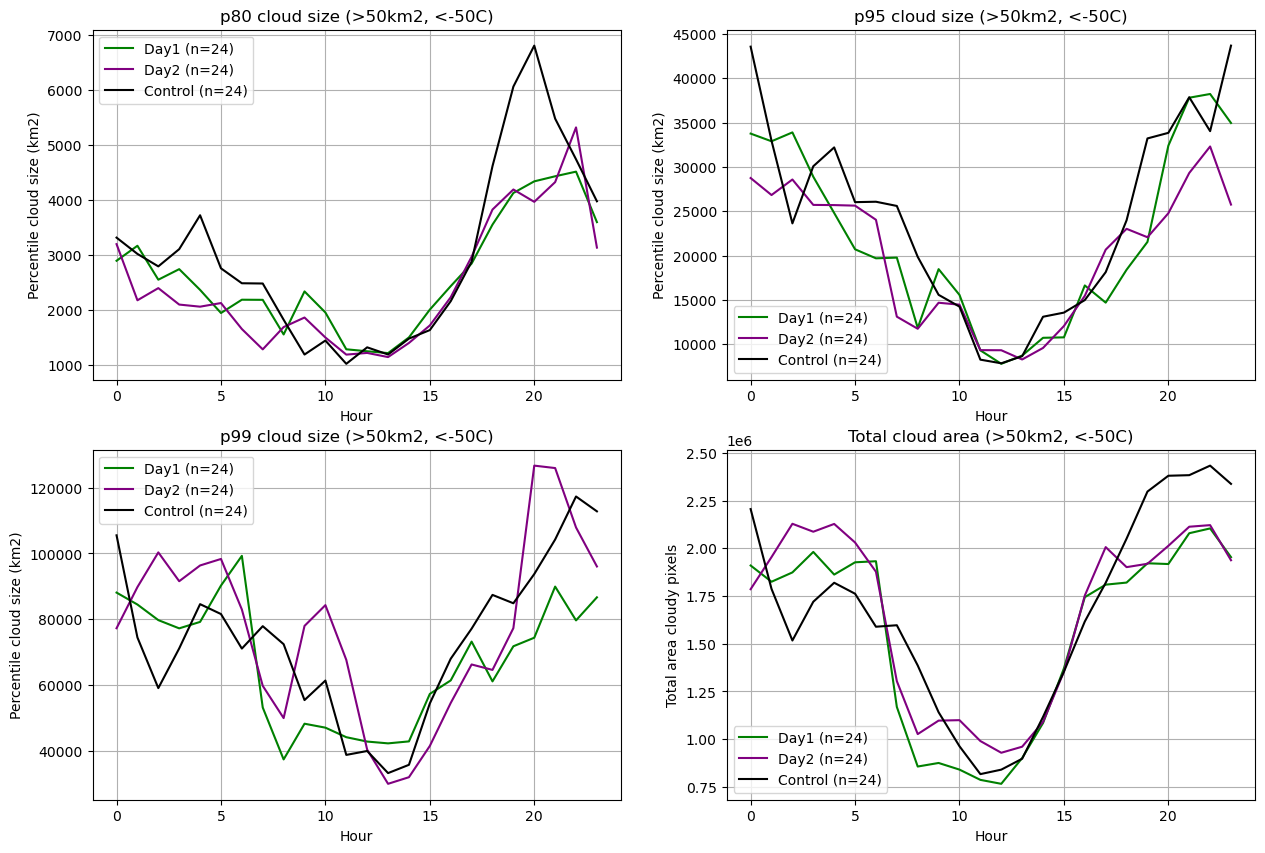

In [131]:
f = plt.figure(figsize=(15, 10))
ax = f.add_subplot(2,2,1)
hours = data.groupby('hour')['area'].quantile(0.80)*1.5**2
plt.plot(hours.index, hours.values, label='Day1 (n={})'.format(len(hours)), color='green')
#####


sensitivity_hours = sensitivity_data.groupby('hour')['area'].quantile(0.80)*1.5**2
plt.plot(sensitivity_hours.index, sensitivity_hours.values, label='Day2 (n={})'.format(len(sensitivity_hours)), color='purple')
############


control_hours = control_data.groupby('hour')['area'].quantile(0.80)*1.5**2
plt.plot(control_hours.index, control_hours.values, label='Control (n={})'.format(len(control_hours)), color='black')

plt.xlabel('Hour')
plt.ylabel('Percentile cloud size (km2)')
plt.title('p80 cloud size (>50km2, <-50C)')
plt.legend()
plt.grid(True)

##############################

ax = f.add_subplot(2,2,2)
hours = data.groupby('hour')['area'].quantile(0.95)*1.5**2
plt.plot(hours.index, hours.values, label='Day1 (n={})'.format(len(hours)), color='green')
#####


sensitivity_hours = sensitivity_data.groupby('hour')['area'].quantile(0.95)*1.5**2
plt.plot(sensitivity_hours.index, sensitivity_hours.values, label='Day2 (n={})'.format(len(sensitivity_hours)), color='purple')
############


control_hours = control_data.groupby('hour')['area'].quantile(0.95)*1.5**2
plt.plot(control_hours.index, control_hours.values, label='Control (n={})'.format(len(control_hours)), color='black')

plt.xlabel('Hour')
plt.ylabel('Percentile cloud size (km2)')
plt.title('p95 cloud size (>50km2, <-50C)')
plt.legend()
plt.grid(True)

##############################
##############################

ax = f.add_subplot(2,2,3)
hours = data.groupby('hour')['area'].quantile(0.99)*1.5**2
plt.plot(hours.index, hours.values, label='Day1 (n={})'.format(len(hours)), color='green')
#####


sensitivity_hours = sensitivity_data.groupby('hour')['area'].quantile(0.99)*1.5**2
plt.plot(sensitivity_hours.index, sensitivity_hours.values, label='Day2 (n={})'.format(len(sensitivity_hours)), color='purple')
############


control_hours = control_data.groupby('hour')['area'].quantile(0.99)*1.5**2
plt.plot(control_hours.index, control_hours.values, label='Control (n={})'.format(len(control_hours)), color='black')

plt.xlabel('Hour')
plt.ylabel('Percentile cloud size (km2)')
plt.title('p99 cloud size (>50km2, <-50C)')
plt.legend()
plt.grid(True)

##############################


###############################


ax = f.add_subplot(2,2,4)
hours = data.groupby('hour')['area'].sum()
plt.plot(hours.index, hours.values, label='Day1 (n={})'.format(len(hours)), color='green')
#####


sensitivity_hours = sensitivity_data.groupby('hour')['area'].sum()
plt.plot(sensitivity_hours.index, sensitivity_hours.values, label='Day2 (n={})'.format(len(sensitivity_hours)), color='purple')
############


control_hours = control_data.groupby('hour')['area'].sum()
plt.plot(control_hours.index, control_hours.values, label='Control (n={})'.format(len(control_hours)), color='black')

plt.xlabel('Hour')
plt.ylabel('Total area cloudy pixels')
plt.title('Total cloud area (>50km2, <-50C)')
plt.legend()
plt.grid(True)

plt.show()
f.savefig('Southern_cloudSnapshotsSize.png', dpi=200)

In [87]:
sensitivity_hours

hour
0.0     11885.811321
1.0     10424.904110
2.0      9891.409524
3.0      9256.765000
4.0      8968.828729
5.0      7775.176796
6.0      7098.509091
7.0      5759.231405
8.0      3929.503876
9.0      5233.250000
10.0     6046.579545
11.0     4272.390909
12.0     3772.307692
13.0     3809.480916
14.0     4329.865385
15.0     5095.944444
16.0     5746.910506
17.0     6987.835664
18.0     8132.232787
19.0     9726.136519
20.0    10014.930403
21.0    10895.074219
22.0    12496.443038
23.0    12289.627193
Name: area, dtype: float64

In [81]:
# Group by date and count the number of hours for each date
date_hour_counts = data.groupby('date')['hour'].nunique()
missing_hours = date_hour_counts[date_hour_counts != 24]
missing_hours

Series([], Name: hour, dtype: int64)

In [82]:
# Group by date and count the number of hours for each date
date_hour_counts = sensitivity_data.groupby('date')['hour'].nunique()
missing_hours = date_hour_counts[date_hour_counts != 24]
missing_hours

Series([], Name: hour, dtype: int64)

In [83]:
# Group by date and count the number of hours for each date
date_hour_counts = control_data.groupby('date')['hour'].nunique()
missing_hours = date_hour_counts[date_hour_counts != 24]
missing_hours

Series([], Name: hour, dtype: int64)

In [69]:
sensitivity_data

,Unnamed: 0,date,month,hour,minute,year,day,area,70area,65area,...,maxlon,maxlat,clon,clat,tminlon,tminlat,tmean,tp1,tp99,stormID
178,0,2006-07-27,7.0,0.0,0.0,2006.0,27.0,6245.0,0.0,1459.0,...,-11.29925,9.01125,-11.64350,9.01125,-11.97425,9.01125,-59.365348,-68.163159,-50.153129,2006-07-27_00:00_3
179,1,2006-07-27,7.0,0.0,0.0,2006.0,27.0,13039.0,2986.0,5584.0,...,-8.81525,9.01125,-10.01000,9.01125,-10.35425,9.01125,-62.774985,-73.507272,-50.405804,2006-07-27_00:00_7
180,2,2006-07-27,7.0,0.0,0.0,2006.0,27.0,1514.0,0.0,0.0,...,-9.09875,9.01125,-9.45650,9.01125,-9.70625,9.01125,-52.651972,-56.259061,-50.048291,2006-07-27_00:00_14
181,3,2006-07-27,7.0,0.0,0.0,2006.0,27.0,545.0,0.0,0.0,...,-9.08525,9.01125,-9.24725,9.01125,-9.20675,9.01125,-52.105547,-55.142222,-50.031262,2006-07-27_00:00_23
182,4,2006-07-27,7.0,0.0,0.0,2006.0,27.0,1428.0,0.0,0.0,...,-8.43725,9.01125,-8.74100,9.01125,-8.55875,9.01125,-54.363020,-61.072774,-50.053238,2006-07-27_00:00_25
183,5,2006-07-27,7.0,0.0,0.0,2006.0,27.0,459.0,0.0,0.0,...,-8.50475,9.01125,-8.76800,9.01125,-8.73425,9.01125,-54.878602,-62.911099,-50.073979,2006-07-27_00:00_26
184,6,2006-07-27,7.0,0.0,0.0,2006.0,27.0,3734.0,210.0,1221.0,...,-7.80275,9.01125,-8.39000,9.01125,-8.08625,9.01125,-61.242291,-72.513008,-50.262318,2006-07-27_00:00_27
185,7,2006-07-27,7.0,0.0,0.0,2006.0,27.0,464.0,0.0,0.0,...,-8.59925,9.01125,-8.75450,9.01125,-8.69375,9.01125,-55.785836,-63.394660,-50.096206,2006-07-27_00:00_28
186,8,2006-07-27,7.0,0.0,0.0,2006.0,27.0,701.0,0.0,3.0,...,-8.09975,9.01125,-8.31575,9.01125,-8.31575,9.01125,-57.853202,-64.883251,-50.308267,2006-07-27_00:00_31
187,9,2006-07-27,7.0,0.0,0.0,2006.0,27.0,59102.0,15260.0,28825.0,...,-3.19925,9.01125,-5.83850,9.01125,-6.34475,9.01125,-64.069853,-77.581067,-50.341963,2006-07-27_00:00_32


In [70]:
control_data[0:24]

,Unnamed: 0,date,month,hour,minute,year,day,area,70area,65area,...,maxlon,maxlat,clon,clat,tminlon,tminlat,tmean,tp1,tp99,stormID
251,0,2006-07-27,7.0,0.0,0.0,2006.0,27.0,1894.0,0.0,0.0,...,-11.74475,9.01125,-11.86625,9.01125,-11.98775,9.01125,-53.989348,-58.480170,-50.091066,2006-07-27_00:00_1
252,1,2006-07-27,7.0,0.0,0.0,2006.0,27.0,3303.0,0.0,0.0,...,-11.31275,9.01125,-11.65025,9.01125,-11.75825,9.01125,-54.373017,-59.077696,-50.090851,2006-07-27_00:00_2
253,2,2006-07-27,7.0,0.0,0.0,2006.0,27.0,8697.0,0.0,2147.0,...,-10.08425,9.01125,-10.81325,9.01125,-10.35425,9.01125,-59.737594,-68.909269,-50.195182,2006-07-27_00:00_5
254,3,2006-07-27,7.0,0.0,0.0,2006.0,27.0,825.0,0.0,0.0,...,-10.55675,9.01125,-10.91450,9.01125,-10.96175,9.01125,-51.659800,-53.494617,-50.046691,2006-07-27_00:00_7
255,4,2006-07-27,7.0,0.0,0.0,2006.0,27.0,1567.0,0.0,0.0,...,-7.97825,9.01125,-8.32250,9.01125,-8.36975,9.01125,-53.824489,-57.751191,-50.122019,2006-07-27_00:00_14
256,5,2006-07-27,7.0,0.0,0.0,2006.0,27.0,37671.0,7188.0,16085.0,...,-4.76525,9.01125,-6.45950,9.01125,-6.12875,9.01125,-63.028453,-74.729437,-50.375201,2006-07-27_00:00_16
257,6,2006-07-27,7.0,0.0,0.0,2006.0,27.0,3592.0,0.0,0.0,...,-6.53375,9.01125,-7.10075,9.01125,-6.89825,9.01125,-57.057520,-64.564828,-50.153060,2006-07-27_00:00_17
258,7,2006-07-27,7.0,0.0,0.0,2006.0,27.0,1540.0,0.0,34.0,...,-6.57425,9.01125,-6.93200,9.01125,-6.77675,9.01125,-56.110711,-66.195238,-50.162778,2006-07-27_00:00_19
259,8,2006-07-27,7.0,0.0,0.0,2006.0,27.0,6110.0,0.0,0.0,...,-4.09025,9.01125,-4.69100,9.01125,-4.40075,9.01125,-54.760005,-59.482570,-50.166355,2006-07-27_00:00_24
260,9,2006-07-27,7.0,0.0,0.0,2006.0,27.0,565.0,0.0,0.0,...,-3.50975,9.01125,-3.71900,9.01125,-3.71225,9.01125,-52.036216,-54.067617,-50.081333,2006-07-27_00:00_30


In [71]:
data[0:24]

,Unnamed: 0,date,month,hour,minute,year,day,area,70area,65area,...,maxlon,maxlat,clon,clat,tminlon,tminlat,tmean,tp1,tp99,stormID
231,0,2006-07-27,7.0,0.0,0.0,2006.0,27.0,2953.0,0.0,0.0,...,-11.46125,9.01125,-11.72450,9.01125,-11.97425,9.01125,-54.134824,-60.058179,-50.063586,2006-07-27_00:00_1
232,1,2006-07-27,7.0,0.0,0.0,2006.0,27.0,7670.0,144.0,2757.0,...,-9.93575,9.01125,-10.59050,9.01125,-10.36775,9.01125,-61.796021,-70.241717,-50.334165,2006-07-27_00:00_3
233,2,2006-07-27,7.0,0.0,0.0,2006.0,27.0,10890.0,268.0,7553.0,...,-6.39875,9.01125,-7.33025,9.01125,-7.00625,9.01125,-64.827577,-70.334111,-50.796089,2006-07-27_00:00_8
234,3,2006-07-27,7.0,0.0,0.0,2006.0,27.0,14478.0,193.0,2842.0,...,-5.83175,9.01125,-7.01300,9.01125,-6.68225,9.01125,-58.358991,-70.235257,-50.171938,2006-07-27_00:00_9
235,4,2006-07-27,7.0,0.0,0.0,2006.0,27.0,7968.0,16.0,189.0,...,-6.61475,9.01125,-7.24925,9.01125,-6.79025,9.01125,-56.314965,-68.272892,-50.174760,2006-07-27_00:00_10
236,5,2006-07-27,7.0,0.0,0.0,2006.0,27.0,27722.0,5249.0,11266.0,...,-4.53575,9.01125,-5.93300,9.01125,-6.18275,9.01125,-62.761214,-73.885612,-50.396767,2006-07-27_00:00_13
237,6,2006-07-27,7.0,0.0,0.0,2006.0,27.0,3613.0,0.0,23.0,...,-4.61675,9.01125,-5.27150,9.01125,-4.77875,9.01125,-55.042574,-64.642945,-50.093326,2006-07-27_00:00_18
238,7,2006-07-27,7.0,0.0,0.0,2006.0,27.0,958.0,0.0,0.0,...,-3.88775,9.01125,-4.11050,9.01125,-4.13075,9.01125,-54.392854,-56.751590,-50.219824,2006-07-27_00:00_24
239,0,2006-07-27,7.0,1.0,0.0,2006.0,27.0,691.0,0.0,0.0,...,-11.71775,9.01125,-11.85275,9.01125,-11.98775,9.01125,-51.458596,-53.606025,-50.028701,2006-07-27_01:00_1
240,1,2006-07-27,7.0,1.0,0.0,2006.0,27.0,1187.0,0.0,0.0,...,-11.42075,9.01125,-11.70425,9.01125,-11.98775,9.01125,-53.250186,-58.303531,-50.051587,2006-07-27_01:00_2


In [61]:
sensitivity_data.tail()

,Unnamed: 0,date,month,hour,minute,year,day,area,70area,65area,...,maxlon,maxlat,clon,clat,tminlon,tminlat,tmean,tp1,tp99,stormID
5483,0,2006-08-12,8.0,23.0,0.0,2006.0,12.0,160042.0,16512.0,40033.0,...,-2.94275,9.01125,-7.26275,9.01125,-5.87225,9.01125,-60.407985,-74.929341,-50.247990,2006-08-12_23:00_1
5484,1,2006-08-12,8.0,23.0,0.0,2006.0,12.0,50812.0,15304.0,29314.0,...,-6.29075,9.01125,-8.87600,9.01125,-9.30125,9.01125,-65.385488,-77.715833,-50.508169,2006-08-12_23:00_3
5485,2,2006-08-12,8.0,23.0,0.0,2006.0,12.0,1775.0,0.0,0.0,...,-10.44875,9.01125,-10.79975,9.01125,-10.79975,9.01125,-54.970492,-58.425480,-50.232987,2006-08-12_23:00_4
5486,3,2006-08-12,8.0,23.0,0.0,2006.0,12.0,464.0,0.0,0.0,...,-5.52125,9.01125,-5.87225,9.01125,-6.06125,9.01125,-51.921291,-54.111243,-50.040605,2006-08-12_23:00_26
5487,4,2006-08-12,8.0,23.0,0.0,2006.0,12.0,13818.0,15.0,1446.0,...,-3.63125,9.01125,-4.73150,9.01125,-5.06225,9.01125,-57.164891,-68.956996,-50.104222,2006-08-12_23:00_28


In [62]:
control_data.tail()

,Unnamed: 0,date,month,hour,minute,year,day,area,70area,65area,...,maxlon,maxlat,clon,clat,tminlon,tminlat,tmean,tp1,tp99,stormID
4828,1,2006-08-12,8.0,23.0,0.0,2006.0,12.0,22139.0,192.0,4333.0,...,-9.03125,9.01125,-10.23275,9.01125,-9.43625,9.01125,-59.683414,-69.958803,-50.338579,2006-08-12_23:00_2
4829,2,2006-08-12,8.0,23.0,0.0,2006.0,12.0,14783.0,2866.0,5712.0,...,-9.19325,9.01125,-10.13825,9.01125,-10.69175,9.01125,-62.014771,-73.444290,-50.250423,2006-08-12_23:00_3
4830,3,2006-08-12,8.0,23.0,0.0,2006.0,12.0,33445.0,4663.0,15854.0,...,-4.29275,9.01125,-5.61575,9.01125,-5.66975,9.01125,-63.301149,-72.762851,-50.371805,2006-08-12_23:00_9
4831,4,2006-08-12,8.0,23.0,0.0,2006.0,12.0,2898.0,0.0,0.0,...,-3.95525,9.01125,-4.33325,9.01125,-4.34675,9.01125,-55.304409,-62.780509,-50.084301,2006-08-12_23:00_13
4832,5,2006-08-12,8.0,23.0,0.0,2006.0,12.0,1135.0,0.0,0.0,...,-2.94275,9.01125,-3.20600,9.01125,-3.01025,9.01125,-55.371970,-60.800032,-50.168537,2006-08-12_23:00_21


In [63]:
data.tail()

,Unnamed: 0,date,month,hour,minute,year,day,area,70area,65area,...,maxlon,maxlat,clon,clat,tminlon,tminlat,tmean,tp1,tp99,stormID
5507,8,2006-08-12,8.0,23.0,0.0,2006.0,12.0,1060.0,0.0,0.0,...,-4.38725,9.01125,-4.63025,9.01125,-4.69775,9.01125,-53.544350,-57.522403,-50.085748,2006-08-12_23:00_36
5508,9,2006-08-12,8.0,23.0,0.0,2006.0,12.0,1290.0,0.0,0.0,...,-3.92825,9.01125,-4.27925,9.01125,-4.34675,9.01125,-52.901119,-57.696345,-50.061272,2006-08-12_23:00_39
5509,10,2006-08-12,8.0,23.0,0.0,2006.0,12.0,593.0,0.0,0.0,...,-4.04975,9.01125,-4.33325,9.01125,-4.48175,9.01125,-52.298535,-55.436227,-50.057470,2006-08-12_23:00_41
5510,11,2006-08-12,8.0,23.0,0.0,2006.0,12.0,514.0,0.0,0.0,...,-3.82025,9.01125,-4.03625,9.01125,-4.18475,9.01125,-51.526122,-53.810971,-50.027606,2006-08-12_23:00_44
5511,12,2006-08-12,8.0,23.0,0.0,2006.0,12.0,1474.0,0.0,0.0,...,-3.56375,9.01125,-3.86075,9.01125,-3.94175,9.01125,-52.160900,-55.800416,-50.039140,2006-08-12_23:00_48


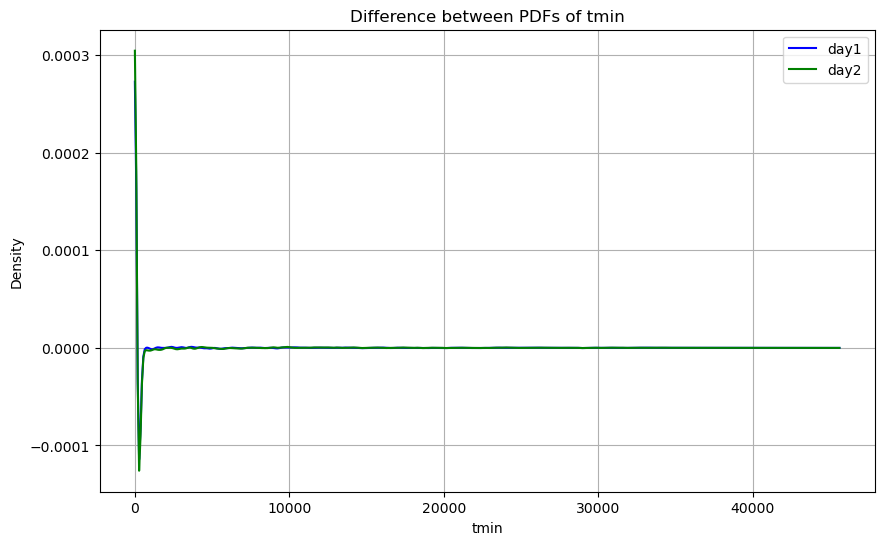

In [161]:
from scipy.stats import gaussian_kde

vars = '70area'
# Calculate the KDEs
kde1 = gaussian_kde(data[vars])
kde2 = gaussian_kde(sensitivity_data[vars])
kde3 = gaussian_kde(control_data[vars])

# Create an x-range that covers both distributions
x_min = min(sensitivity_data[vars].min(), control_data[vars].min())
x_max = max(sensitivity_data[vars].max(), control_data[vars].max())
x_range = np.linspace(x_min, x_max, 500)

# Evaluate the PDFs
pdf1 = kde1(x_range)
pdf2 = kde2(x_range)
pdf3 = kde3(x_range)

pdf_diff1 = pdf1 - pdf3
pdf_diff2 = pdf2-pdf3

# Plot the PDF using seaborn
plt.figure(figsize=(10, 6))
plt.plot(x_range, pdf_diff1, label='day1', color='blue')
plt.plot(x_range, pdf_diff2, label='day2', color='green')
#plt.plot(x_range, pdf_difference, label='Difference (Dataset 1 - Dataset 2)', color='red')
plt.xlabel('tmin')
plt.ylabel('Density')
plt.title('Difference between PDFs of tmin')
plt.legend()
plt.grid(True)

plt.show()

In [39]:
%load_ext autoreload
%autoreload 2
from GLOBAL import SM_runs_diurnalRain

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
d1, d2, cont = SM_runs_diurnalRain.run()

888
888
888
Entering multiprocessing
Entering multiprocessing
Entering multiprocessing


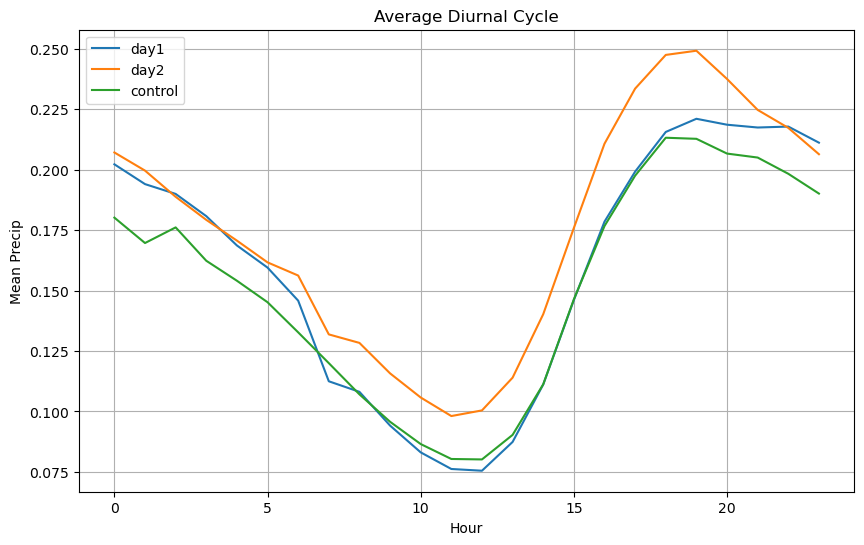

In [8]:
plt.figure(figsize=(10, 6))
labels = ['day1', 'day2', 'control']
for idx, df in enumerate([d1,d2,cont]):
    plt.plot(df['hour'], df*3600, label=labels[idx])

plt.xlabel('Hour')
plt.ylabel('Mean Precip')
plt.title('Average Diurnal Cycle')
plt.legend()
plt.grid(True)
plt.show()

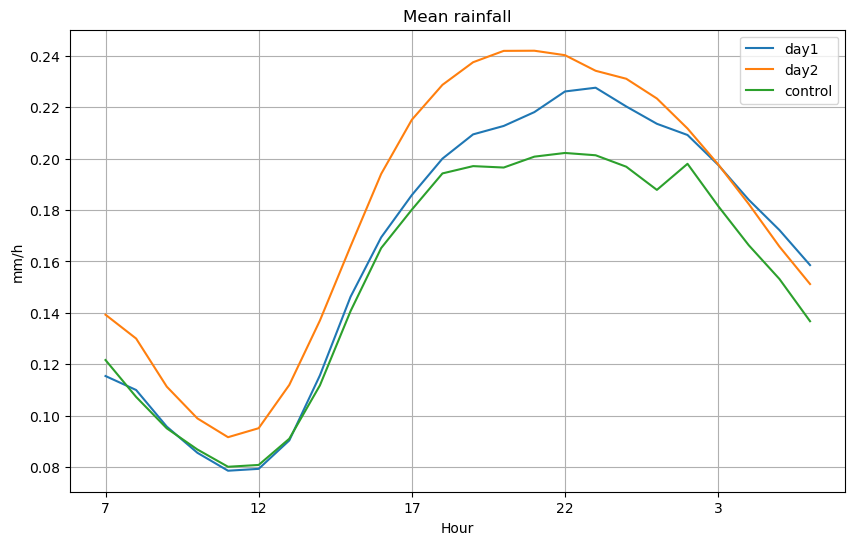

In [42]:
f = plt.figure(figsize=(10, 6))
ax = f.add_subplot(111)
labels = ['day1', 'day2', 'control']
for idx, df in enumerate([d1,d2,cont]):
    df = df.roll(hour=-7)*3600
    ax.plot(df['hour'], df, label=labels[idx])
    
ax.set_xticklabels([0,7,12,17,22,3])
plt.xlabel('Hour')
plt.ylabel('mm/h')
plt.title('Mean rainfall')
plt.legend()
plt.grid(True)
plt.show()
f.savefig('meanRainfall_15W20E_9-20N.png')

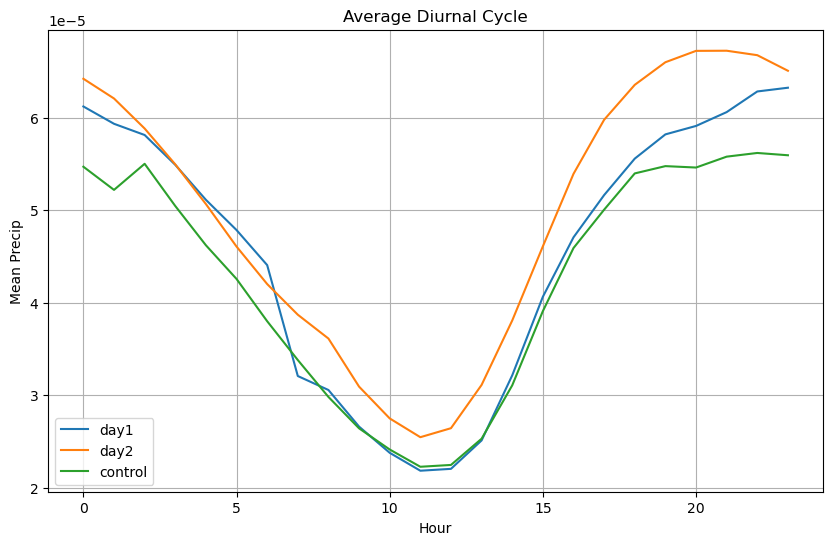

In [33]:
f = plt.figure(figsize=(10, 6))
ax = f.add_subplot(111)
labels = ['day1', 'day2', 'control']
for idx, df in enumerate([d1,d2,cont]):
    #df = df.roll(hour=-6)*3600
    ax.plot(df['hour'], df, label=labels[idx])
    
#ax.set_xticklabels([0,6,11,16,21,2])
plt.xlabel('Hour')
plt.ylabel('Mean Precip')
plt.title('Average Diurnal Cycle')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
d1_rainy, d2_rainy, cont_rainy = SM_runs_diurnalRain.run()

888
888
888
Entering multiprocessing
Entering multiprocessing
Entering multiprocessing


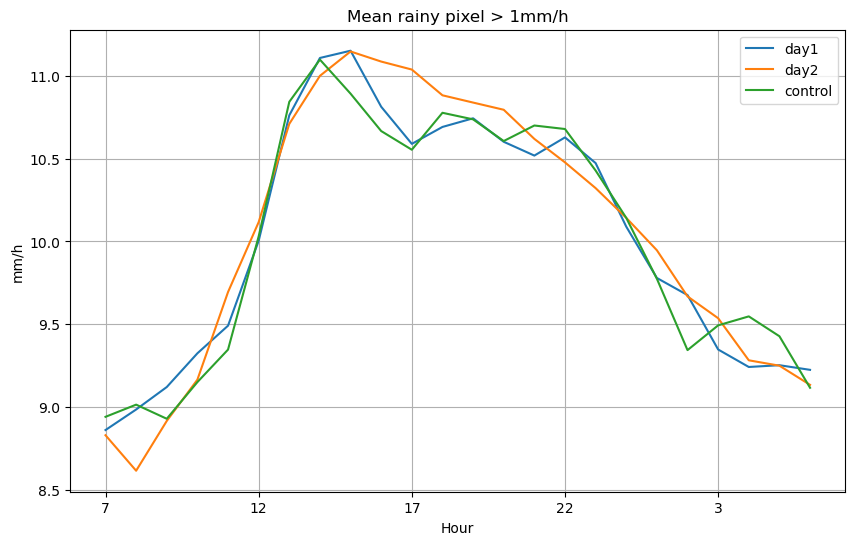

In [43]:
f = plt.figure(figsize=(10, 6))
ax = f.add_subplot(111)
labels = ['day1', 'day2', 'control']
for idx, df in enumerate([d1_rainy,d2_rainy,cont_rainy]):
    df = df.roll(hour=-7)
    ax.plot(df['hour'], df, label=labels[idx])
    
ax.set_xticklabels([0,7,12,17,22,3])
plt.xlabel('Hour')
plt.ylabel('mm/h')
plt.title('Mean rainy pixel > 1mm/h')
plt.legend()
plt.grid(True)
plt.show()
f.savefig('meanRainyPixel_15W20E_9-20N.png')

In [1]:
import dask_gateway

# Create a connection to dask-gateway.
gw = dask_gateway.Gateway("https://dask-gateway.jasmin.ac.uk", auth="jupyterhub")

# Inspect and change the options if required before creating your cluster.
options = gw.cluster_options()
options.worker_cores = 2

# Create a dask cluster, or, if one already exists, connect to it.
# This stage creates the scheduler job in SLURM, so may take some time.
# While your job queues.
clusters = gw.list_clusters()
if not clusters:
    cluster = gw.new_cluster(options, shutdown_on_close=False)
else:
    cluster = gw.connect(clusters[0].name)

# Create at least one worker, and allow your cluster to scale to three.
cluster.adapt(minimum=1, maximum=3)

# Get a dask client.
client = cluster.get_client()

GatewayClusterError: Cluster '9171e0017c0441a782d52e8261d068ff' failed to start, see logs for more information